### Imports

In [1]:
import os
import sys
import pickle
from skimage.io import imread
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
sys.path.append('/home/dafei/git/AutoDS3D/')
from DS3Dplus.ds3d_utils import calc_jaccard_rmse

### Functions

In [3]:
def plot_3d_localizations(image, xyz_gt, xyz_pred1, xyz_pred2,metrics1,metrics2, title, path, label1='Model 1 Predictions', label2='Model 2 Predictions'):
    fig,ax = plt.subplots(1,2,figsize=(16,8))
    ax[0].imshow(image, cmap='gray')
    #ax[0].set_title(title)
    ax[0].axis('off')
    ax[1] = fig.add_subplot(122, projection='3d')
    ax[1].scatter(xyz_gt[:, 0], xyz_gt[:, 1], xyz_gt[:, 2], c='g', marker='o', label='Ground Truth', alpha=0.5)
    ax[1].scatter(xyz_pred1[:, 0], xyz_pred1[:, 1], xyz_pred1[:, 2], c='b', marker='^', label=label1, alpha=0.5)
    ax[1].scatter(xyz_pred2[:, 0], xyz_pred2[:, 1], xyz_pred2[:, 2], c='r', marker='s', label=label2, alpha=0.5)
    if metrics1['Jaccard'] == 0.0:
        ax[1].text2D(0.05, 0.95, f"{label1} - Jaccard: {metrics1['Jaccard']}, RMSE_xy: {metrics1['RMSE_xy (nm)']} nm, RMSE_z: {metrics1['RMSE_z (nm)']} nm", transform=ax[1].transAxes, color='blue')
    else:
        ax[1].text2D(0.05, 0.95, f"{label1} - Jaccard: {metrics1['Jaccard']:.3f}, RMSE_xy: {metrics1['RMSE_xy (nm)']:.1f} nm, RMSE_z: {metrics1['RMSE_z (nm)']:.1f} nm", transform=ax[1].transAxes, color='blue')
    if metrics2['Jaccard'] == 0.0:
        ax[1].text2D(0.05, 0.90, f"{label2} - Jaccard: {metrics2['Jaccard']}, RMSE_xy: {metrics2['RMSE_xy (nm)']} nm, RMSE_z: {metrics2['RMSE_z (nm)']} nm", transform=ax[1].transAxes, color='red')
    else:
        ax[1].text2D(0.05, 0.90, f"{label2} - Jaccard: {metrics2['Jaccard']:.3f}, RMSE_xy: {metrics2['RMSE_xy (nm)']:.1f} nm, RMSE_z: {metrics2['RMSE_z (nm)']:.1f} nm", transform=ax[1].transAxes, color='red')
    ax[1].set_xlabel('X (um)')
    ax[1].set_ylabel('Y (um)')
    ax[1].set_zlabel('Z (um)')
    #ax[1].set_title(title)
    ax[1].legend()
    plt.savefig(path)
    plt.close()

In [4]:
def save_non_aberrated_image_comparison(x_folder, localizations, df_autods3d, df_vit, output_dir):
    # check image folder
    if os.path.basename(x_folder) != 'orig':
        raise ValueError(f"x_folder should be 'orig' folder containing non-aberrated images, got {x_folder}")
    for img_name in df_autods3d['Image'].unique():
        xyzps_gt = localizations[img_name]
        xyz_gt = xyzps_gt['xyzps'][:, :-1]
        image_path = os.path.join(x_folder, img_name)
        im = imread(image_path)
        xyz_pred_autods3d = df_autods3d[df_autods3d['Image'] == img_name][['x', 'y', 'z']].to_numpy()
        jaccard_autods3d, rmse_xy_autods3d, rmse_z_autods3d, _ = calc_jaccard_rmse(
                xyz_gt, xyz_pred_autods3d, 0.1)
        if jaccard_autods3d != 0.0:
            metrics_autods3d = {
                'Jaccard': jaccard_autods3d,
                'RMSE_xy (nm)': rmse_xy_autods3d*1000,
                'RMSE_z (nm)': rmse_z_autods3d*1000
            }
        else:
            metrics_autods3d = {
                'Jaccard': 0.0,
                'RMSE_xy (nm)': None,
                'RMSE_z (nm)': None
            }
        xyz_pred_vit = df_vit[df_vit['Image'] == img_name][['x', 'y', 'z']].to_numpy()
        jaccard_vit, rmse_xy_vit, rmse_z_vit, _ = calc_jaccard_rmse(
                xyz_gt, xyz_pred_vit, 0.1)
        if jaccard_vit != 0.0:
            metrics_vit = {
                'Jaccard': jaccard_vit,
                'RMSE_xy (nm)': rmse_xy_vit*1000,
                'RMSE_z (nm)': rmse_z_vit*1000
            }
        else:
            metrics_vit = {
                'Jaccard': 0.0,
                'RMSE_xy (nm)': None,
                'RMSE_z (nm)': None
            }
        path = os.path.join(output_dir, f"{img_name}_comparison.png")
        plot_3d_localizations(im, xyz_gt, xyz_pred_autods3d, xyz_pred_vit, metrics_autods3d, metrics_vit, img_name, path,
                            label1='AutoDS3D Predictions', label2='ViT Predictions')

### Inputs

Plot metrics histograms

In [19]:
autods3d_results_path = '/home/dafei/git/AutoDS3D/experiments/mixed_aberration_dataset/results_aberrated.csv'
vit_results_path = '/home/dafei/output/vitstorm/overfit/results/denoiser_evaluation/40_mixed_images_12_heads_baseline/results_denoiser_aberrated.csv'

In [20]:
df_autods3d_results = pd.read_csv(autods3d_results_path)
df_autods3d_results['RMSE_xy (nm)'] = df_autods3d_results['RMSE_xy (nm)'] * 1000
df_autods3d_results['RMSE_z (nm)'] = df_autods3d_results['RMSE_z (nm)'] * 1000

df_vit_results = pd.read_csv(vit_results_path)

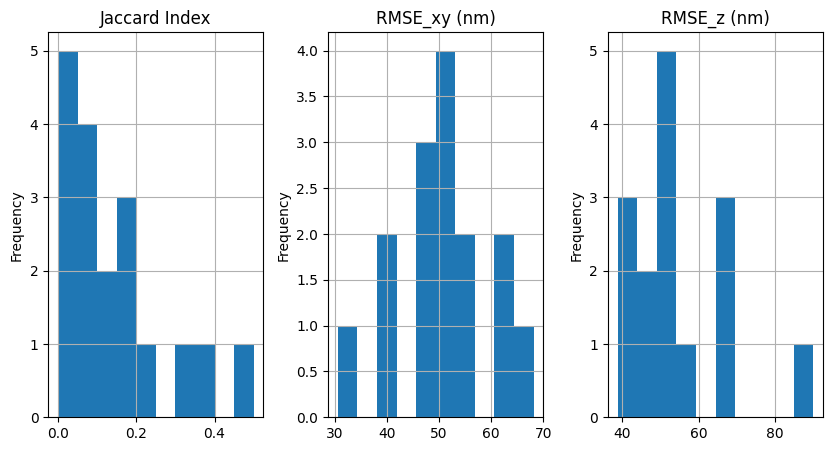

In [21]:
axes = df_autods3d_results.hist(layout=(1, 3), figsize=(10, 5))
for ax in axes.flatten():
    ax.set_ylabel("Frequency")

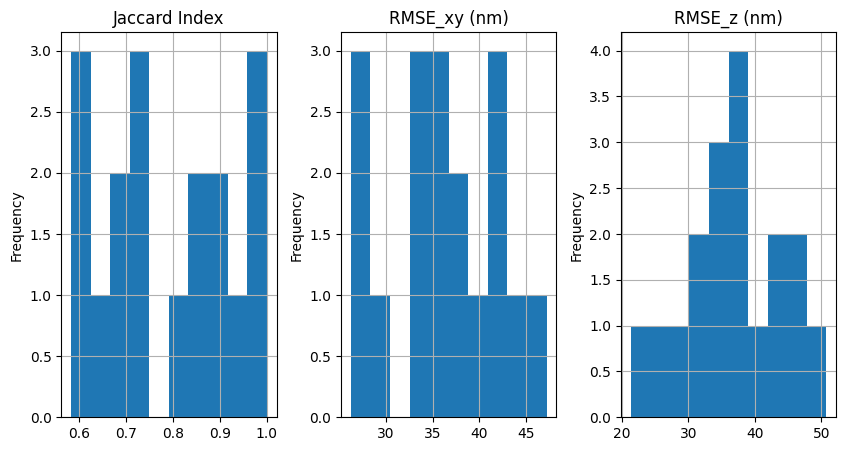

In [22]:
axes = df_vit_results.hist(layout=(1, 3), figsize=(10, 5))
for ax in axes.flatten():
    ax.set_ylabel("Frequency")

Compare models localizations

In [ ]:
autods3d_localizations_path = '/home/dafei/git/AutoDS3D/experiments/mixed_aberration_dataset/localizations_clean.csv'
vit_localizations_path = "/home/dafei/output/vitstorm/overfit/results/denoiser_evaluation/40_mixed_images_12_heads_baseline/localizations_denoiser_clean.csv"

In [10]:
df_autods3d = pd.read_csv(autods3d_localizations_path)
df_vit = pd.read_csv(vit_localizations_path)

if df_autods3d.columns.tolist() != df_vit.columns.tolist():
    raise ValueError("The columns of the two dataframes do not match.")
if df_autods3d.columns.tolist() != ['Image', 'x', 'y', 'z']:
    raise ValueError("The expected columns are: ['Image', 'x', 'y', 'z'].")

In [11]:
data_dir = "/home/dafei/data/ds3d/optical_aberration_pairs/40_images_pairs__with_no_aberration_pairs/"

In [12]:
output_dir = "/home/dafei/git/AutoDS3D/experiments/model_comparisons_autods3d_vs_denoiser_non_abr_imgs/"
os.makedirs(output_dir, exist_ok=True)

In [13]:
with open(os.path.join(data_dir, 'y.pickle'), 'rb') as handle:
    localizations = pickle.load(handle)

with open(os.path.join(data_dir, 'param.pickle'), 'rb') as handle:
        param_dict_test_data = pickle.load(handle)

x_folder = os.path.join(data_dir, 'x/orig')

/tmp/ipykernel_2305733/2821626686.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  localizations = pickle.load(handle)
/tmp/ipykernel_2305733/2821626686.py:5: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If tha

In [14]:
save_non_aberrated_image_comparison(x_folder, localizations, df_autods3d, df_vit, output_dir)